In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

dataset_path = r"C:\Users\saksh\Downloads\project 5\part-2-cnn-computer-vision\part_2_cnn_computer_vision\images"

classes = [folder for folder in os.listdir(dataset_path)
           if os.path.isdir(os.path.join(dataset_path, folder))]

print("Classes:", classes)

for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    num_images = len(os.listdir(class_path))

    print(f"{class_name}: {num_images} images")

Classes: ['dent', 'normal', 'scratch', 'stain']
dent: 120 images
normal: 120 images
scratch: 120 images
stain: 120 images


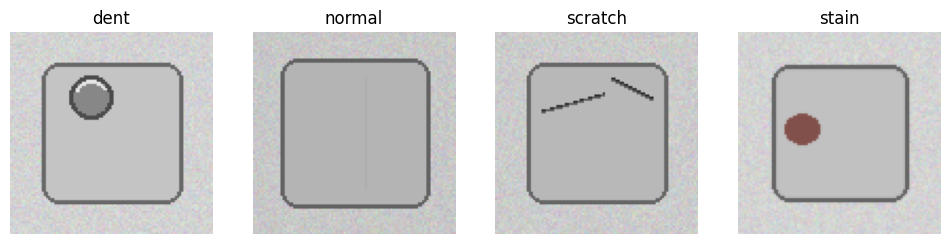

Image Shape: (96, 96, 3)


In [ ]:
plt.figure(figsize=(12,5))

for i, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    img = cv2.imread(image_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,4,i+1)

    plt.imshow(img)

    plt.title(class_name)

    plt.axis("off")

plt.show()

sample_image = image_path

img = cv2.imread(sample_image)

print("Image Shape:", img.shape)

# The dataset contains four image classes: normal, scratch, dent, and stain.

# Each class contains images related to different product surface conditions.

# The sample images show visible differences between defects, which will help the CNN learn image patterns.

# Most images have similar dimensions, making preprocessing easier.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 128
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128,128,3)
))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\saksh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.2240 - loss: 2.3411 - val_accuracy: 0.3021 - val_loss: 1.3944
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 547ms/step - accuracy: 0.2812 - loss: 1.3753 - val_accuracy: 0.4896 - val_loss: 1.3522
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 315ms/step - accuracy: 0.4401 - loss: 1.3155 - val_accuracy: 0.4062 - val_loss: 1.2748
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 405ms/step - accuracy: 0.5130 - loss: 1.1881 - val_accuracy: 0.4583 - val_loss: 1.1503
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 568ms/step - accuracy: 0.5859 - loss: 0.9997 - val_accuracy: 0.6250 - val_loss: 0.9517
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 536ms/step - accuracy: 0.7188 - loss: 0.8062 - val_accuracy: 0.7604 - val_loss: 0.6880
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 558ms/step - accuracy: 0.7682 - loss: 0.6849 - val_accuracy: 0.7292 - val_loss: 0.6333
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 453ms/step - accuracy: 0.7734 - loss: 0.5877 - val_accuracy: 0.70

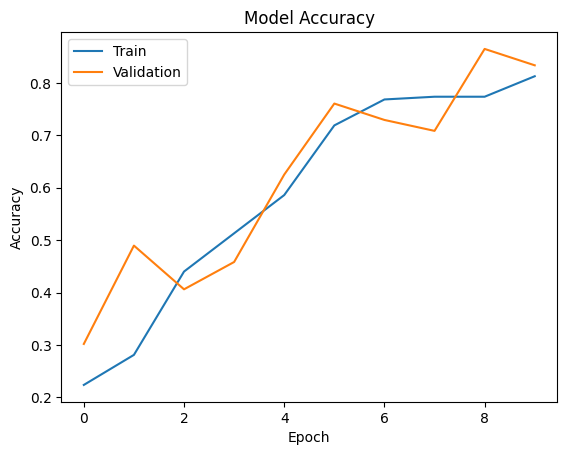

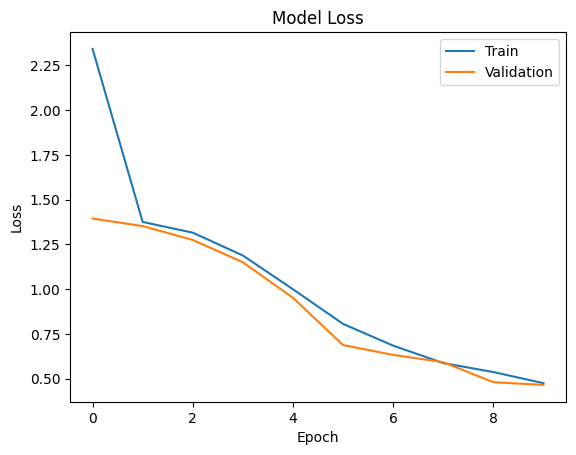

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

In [14]:
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 357ms/step - accuracy: 0.8750 - loss: 0.4526
Validation Loss: 0.452649861574173
Validation Accuracy: 0.875


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step


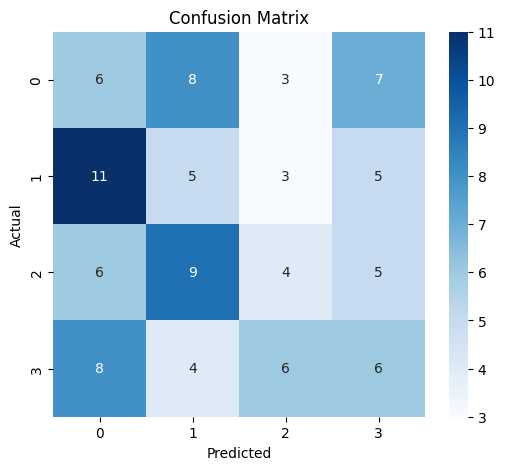

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)

y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step


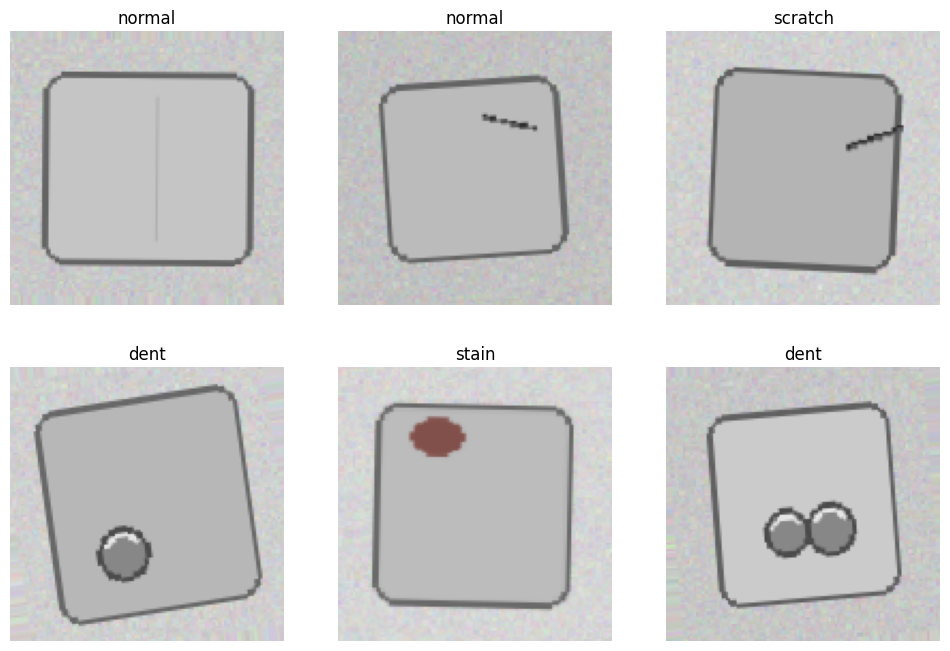

In [ ]:
images, labels = next(val_data)

preds = model.predict(images)

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    predicted_class = np.argmax(preds[i])

    class_name = list(train_data.class_indices.keys())[predicted_class]

    plt.title(class_name)

    plt.axis("off")

plt.savefig("prediction_outputs.png")

plt.show()